Carga de archivos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)


# Cargar el archivo
df = pd.read_csv('heart_attack_prediction_dataset.csv')

# Ver las primeras 5 filas
print(df.head())

  Patient ID  Age     Sex  Cholesterol Blood Pressure  Heart Rate  Diabetes  \
0    BMW7812   67    Male          208         158/88          72         0   
1    CZE1114   21    Male          389         165/93          98         1   
2    BNI9906   21  Female          324         174/99          72         1   
3    JLN3497   84    Male          383        163/100          73         1   
4    GFO8847   66    Male          318          91/88          93         1   

   Family History  Smoking  Obesity  ...  Sedentary Hours Per Day  Income  \
0               0        1        0  ...                 6.615001  261404   
1               1        1        1  ...                 4.963459  285768   
2               0        0        0  ...                 9.463426  235282   
3               1        1        0  ...                 7.648981  125640   
4               1        1        1  ...                 1.514821  160555   

         BMI  Triglycerides  Physical Activity Days Per Week  

Borrar Columnas

In [2]:
# Lista de las 4 columnas que quieres eliminar
columnas_a_eliminar = ['Patient ID', 'Blood Pressure', 'Country', 'Continent', 'Hemisphere']

# Borrar y guardar en un nuevo DataFrame (o sobreescribir el actual)
df = df.drop(columns=columnas_a_eliminar)

# O bien, usando el parámetro axis:
# df = df.drop(['col1', 'col2', 'col3', 'col4'], axis=1)

codificación one_hot

In [3]:
data_encoded = pd.get_dummies(df, columns=['Sex', 'Diet'],  
drop_first=False, dtype=int) 

data_encoded.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,...,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Sex_Female,Sex_Male,Diet_Average,Diet_Healthy,Diet_Unhealthy
0,67,208,72,0,0,1,0,0,4.168189,0,...,31.251233,286,0,6,0,0,1,1,0,0
1,21,389,98,1,1,1,1,1,1.813242,1,...,27.194973,235,1,7,0,0,1,0,0,1
2,21,324,72,1,0,0,0,0,2.078353,1,...,28.176571,587,4,4,0,1,0,0,1,0
3,84,383,73,1,1,1,0,1,9.828130,1,...,36.464704,378,3,4,0,0,1,1,0,0
4,66,318,93,1,1,1,1,0,5.804299,1,...,21.809144,231,1,5,0,0,1,0,0,1


Heart Attack Risk guardada como y

y el resto como x

In [4]:
y = data_encoded['Heart Attack Risk']

x=data_encoded.drop(columns=['Heart Attack Risk'])

Modelo de regresión logística

In [5]:
from sklearn.preprocessing import StandardScaler

# Crear el scaler
scaler = StandardScaler()

# Escalar todos los datos X usando Z-score
X_scaled = scaler.fit_transform(x)

# Ver resultado
print(X_scaled)

[[ 6.25557131e-01 -6.41578894e-01 -1.47042098e-01 ...  1.41748791e+00
  -7.14199547e-01 -7.01666953e-01]
 [-1.53932232e+00  1.59689495e+00  1.11817855e+00 ... -7.05473389e-01
  -7.14199547e-01  1.42517757e+00]
 [-1.53932232e+00  7.93023127e-01 -1.47042098e-01 ... -7.05473389e-01
   1.40016891e+00 -7.01666953e-01]
 ...
 [-3.15694803e-01 -1.22154025e-01  1.45881488e+00 ...  1.41748791e+00
  -7.14199547e-01 -7.01666953e-01]
 [-8.33383367e-01 -1.01259666e+00 -7.30990089e-01 ... -7.05473389e-01
  -7.14199547e-01  1.42517757e+00]
 [-1.35107193e+00  1.18877541e+00 -1.05510022e-03 ... -7.05473389e-01
   1.40016891e+00 -7.01666953e-01]]


In [6]:
#creamos el modelo de regresión logística 
modelo_log = LogisticRegression(max_iter=1000000)
# ajustamos el modelo a los datos. 
modelo_log.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Validación K-Folds

In [7]:
scores_lr = cross_val_score(
    modelo_log,
    X_scaled,
    y,
    cv=10,
    scoring='accuracy'
)

print(scores_lr)

[0.64196123 0.64196123 0.64196123 0.64269406 0.64155251 0.64155251
 0.64155251 0.64155251 0.64155251 0.64155251]


KNN

In [8]:
from sklearn.model_selection import validation_curve

# Para KNN:
k = np.arange(1, 21)

modelo1 = KNeighborsClassifier(metric='euclidean')

train_score, val_score = validation_curve(
    modelo1,
    X_scaled,
    y,
    param_name='n_neighbors',
    scoring='f1',
    param_range=k,
    cv=10
)

better_k = k[np.argmax(np.median(val_score, axis=1))]
print(better_k)

1


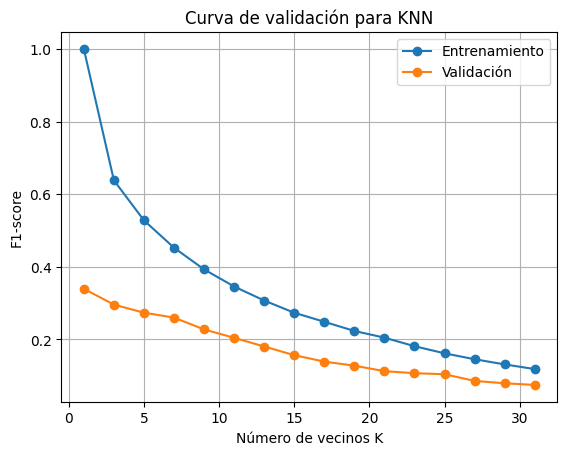

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline


knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

k_values = list(range(1, 32, 2))

train_scores, val_scores = validation_curve(
    knn_model,
    X_scaled,
    y,
    param_name='model__n_neighbors',
    param_range=k_values,
    cv=5,
    scoring='f1'
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(k_values, train_mean, marker='o', label='Entrenamiento')
plt.plot(k_values, val_mean, marker='o', label='Validación')
plt.xlabel('Número de vecinos K')
plt.ylabel('F1-score')
plt.title('Curva de validación para KNN')
plt.legend()
plt.grid()
plt.show()

Mejor grado: 3